# Importación de un modelo con datos de ventas de casas (housing.csv)

In [63]:
import pandas as pd
import numpy as np
import os
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('housing.csv')


# EDA completo siguiendo los modelos anteriores 
# Feature engineering 

### Muestra de la base de datos

In [64]:
df.sample(5)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
25,8540000,6540,4,2,2,yes,yes,yes,no,yes,2,yes,furnished
251,4515000,3450,3,1,2,yes,no,yes,no,no,1,no,semi-furnished
367,3675000,3630,2,1,1,yes,no,no,no,yes,0,no,unfurnished
14,9240000,7800,3,2,2,yes,no,no,no,no,0,yes,semi-furnished
45,7560000,6000,3,2,3,yes,no,no,no,yes,0,no,semi-furnished


### head

In [65]:
df.head(5)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


### tail

In [66]:
df.tail(5)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
540,1820000,3000,2,1,1,yes,no,yes,no,no,2,no,unfurnished
541,1767150,2400,3,1,1,no,no,no,no,no,0,no,semi-furnished
542,1750000,3620,2,1,1,yes,no,no,no,no,0,no,unfurnished
543,1750000,2910,3,1,1,no,no,no,no,no,0,no,furnished
544,1750000,3850,3,1,2,yes,no,no,no,no,0,no,unfurnished


### shape de la base de datos

In [67]:
df.shape

(545, 13)

### info de la base de datos

In [68]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


### valores nulos

In [69]:
print('Existen ', df.isnull().sum().sum(),' valores no existentes')

Existen  0  valores no existentes


### cambiar de formato los valores de tipo float

In [70]:
pd.set_option('display.float_format',lambda x:'%.1f'%x)

### describe

In [71]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
price,545.0,4766729.2,1870439.6,1750000.0,3430000.0,4340000.0,5740000.0,13300000.0
area,545.0,5150.5,2170.1,1650.0,3600.0,4600.0,6360.0,16200.0
bedrooms,545.0,3.0,0.7,1.0,2.0,3.0,3.0,6.0
bathrooms,545.0,1.3,0.5,1.0,1.0,1.0,2.0,4.0
stories,545.0,1.8,0.9,1.0,1.0,2.0,2.0,4.0
parking,545.0,0.7,0.9,0.0,0.0,0.0,1.0,3.0


### cantidad de valores unicos

In [72]:
df.nunique()

price               219
area                284
bedrooms              6
bathrooms             4
stories               4
mainroad              2
guestroom             2
basement              2
hotwaterheating       2
airconditioning       2
parking               4
prefarea              2
furnishingstatus      3
dtype: int64

### tipo de datos en el dataframe

In [73]:
df.dtypes

price                int64
area                 int64
bedrooms             int64
bathrooms            int64
stories              int64
mainroad            object
guestroom           object
basement            object
hotwaterheating     object
airconditioning     object
parking              int64
prefarea            object
furnishingstatus    object
dtype: object

# EDA completo siguiendo los modelos anteriores estandarización, eliminación, nuevas columnas.

### muestra de datos

In [74]:
df.sample(5)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
392,3500000,3990,3,1,2,yes,no,no,no,no,0,no,semi-furnished
293,4200000,4410,2,1,1,no,no,no,no,no,1,no,unfurnished
145,5600000,5000,3,1,4,yes,no,no,no,no,0,no,furnished
265,4403000,2880,3,1,2,yes,no,no,no,no,0,yes,semi-furnished
201,4900000,4095,3,1,2,no,yes,yes,no,yes,0,no,semi-furnished


### estandarización de datos

### Pasar el yes y no a 1 y 0 en las columnas: mainroad, guestroom, basement, hotwaterheating, airconditioning y prefarea. En la columna furnishingstatus se pasa unfurnished, semi-furnished y furnished a 3,2 y 1.

In [75]:
df['mainroad'] = df['mainroad'].replace({'yes':1,'no':0},regex=True)
df['guestroom'] = df['guestroom'].replace({'yes':1,'no':0},regex=True)
df['basement'] = df['basement'].replace({'yes':1,'no':0},regex=True)
df['hotwaterheating'] = df['hotwaterheating'].replace({'yes':1,'no':0},regex=True)
df['airconditioning'] = df['airconditioning'].replace({'yes':1,'no':0},regex=True)
df['prefarea'] = df['prefarea'].replace({'yes':1,'no':0},regex=True)
df['furnishingstatus'] = df['furnishingstatus'].replace({'unfurnished':3,'semi-furnished':2,'furnished':1},regex=True)

/var/folders/gb/nv8xcn1n2fj8nvh2rrjytk0r0000gn/T/ipykernel_1258/4235739201.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['mainroad'] = df['mainroad'].replace({'yes':1,'no':0},regex=True)
/var/folders/gb/nv8xcn1n2fj8nvh2rrjytk0r0000gn/T/ipykernel_1258/4235739201.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['guestroom'] = df['guestroom'].replace({'yes':1,'no':0},regex=True)
/var/folders/gb/nv8xcn1n2fj8nvh2rrjytk0r0000gn/T/ipykernel_1258/4235739201.py:3: FutureWarning: Downcasting behavior in `replace` is deprecate

### muestra de la base de datos

In [76]:
df.sample(5)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
524,2380000,3264,2,1,1,1,0,0,0,0,0,0,3
345,3850000,2015,3,1,2,1,0,1,0,0,0,1,2
205,4900000,6300,3,1,1,1,0,0,0,1,2,0,2
468,3010000,2835,2,1,1,1,0,0,0,0,0,0,2
153,5530000,3300,3,3,2,1,0,1,0,0,0,0,2


### info de la base datos

In [77]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   price             545 non-null    int64
 1   area              545 non-null    int64
 2   bedrooms          545 non-null    int64
 3   bathrooms         545 non-null    int64
 4   stories           545 non-null    int64
 5   mainroad          545 non-null    int64
 6   guestroom         545 non-null    int64
 7   basement          545 non-null    int64
 8   hotwaterheating   545 non-null    int64
 9   airconditioning   545 non-null    int64
 10  parking           545 non-null    int64
 11  prefarea          545 non-null    int64
 12  furnishingstatus  545 non-null    int64
dtypes: int64(13)
memory usage: 55.5 KB


### Matriz de corrrelación

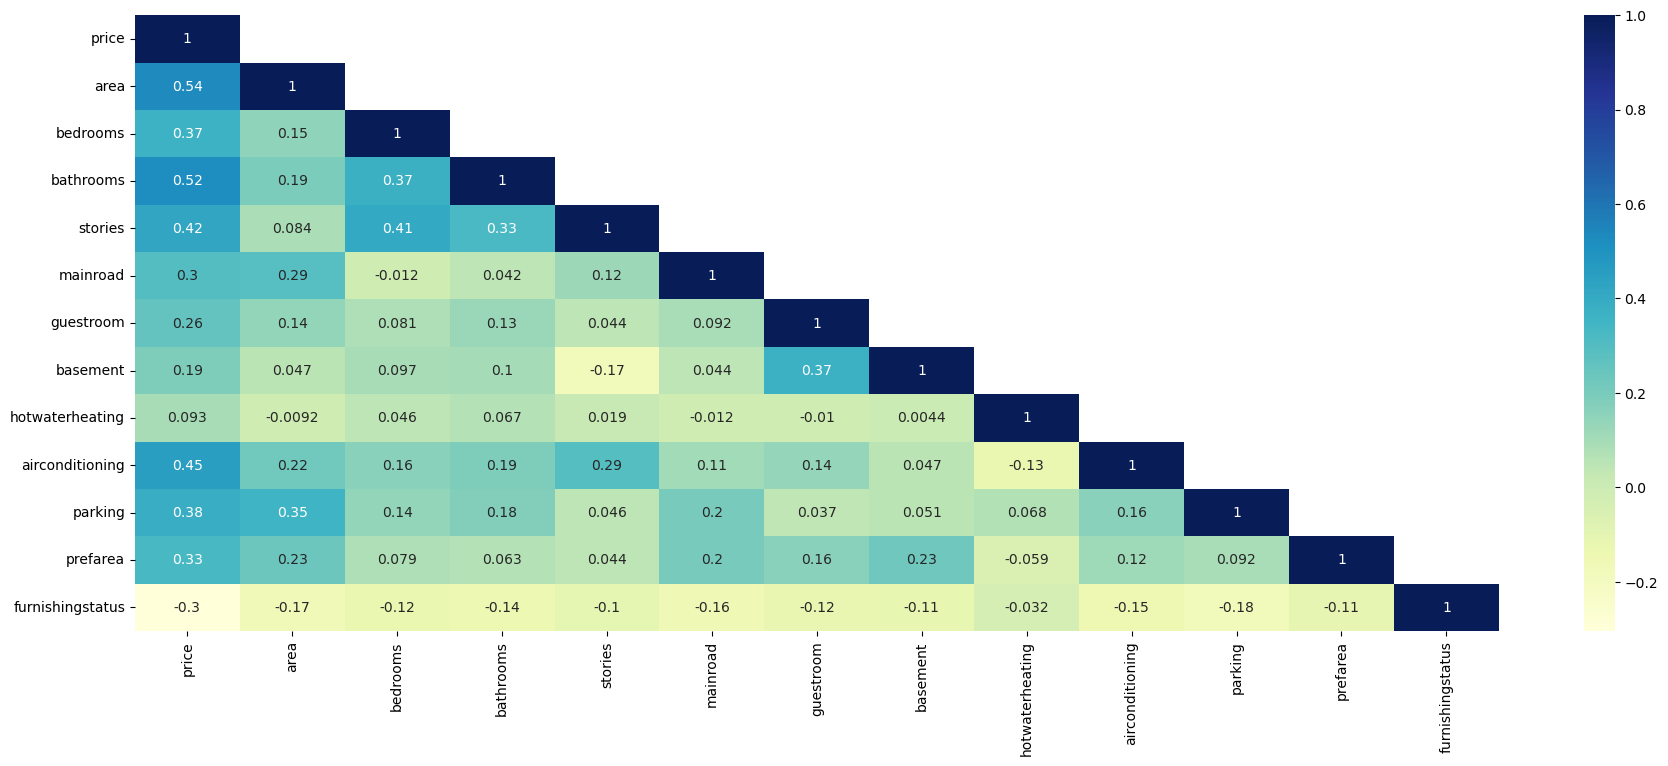

In [78]:
plt.figure(figsize=(22,8))
corr_df = corr = df.corr(method='pearson',numeric_only=True)
df_lt = corr_df.where(np.tril(np.ones(corr_df.shape)).astype(bool))
hmap=sns.heatmap(df_lt, cmap='YlGnBu',annot=True)

La matriz de correlación muestra que las relaciones lineales entre las variables independientes son, en general, bajas o moderadas. La mayoría de los coeficientes de correlación se encuentran por debajo de ±0.40, lo que indica una asociación débil entre los predictores.
Debido a que no existen pares de variables con correlaciones elevadas, se concluye que las variables independientes aportan información relativamente distinta al modelo y que la multicolinealidad no representa un problema significativo. Por lo tanto, no es necesario eliminar variables con base únicamente en el análisis de correlación.
Adicionalmente, la ausencia de correlaciones altas sugiere que los coeficientes estimados en un modelo de regresión serán más estables e interpretables, reduciendo el riesgo de inflar los errores estándar y de generar inferencias poco confiables.

In [79]:
print('Lista completa de columnas')
print('---------------------------------------------------------------------------')
print(df.columns)
print(len(df.columns),' columnas')

cols_num = ['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus']

Lista completa de columnas
---------------------------------------------------------------------------
Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='object')
13  columnas


### Histogramas de las variables en la base de datos

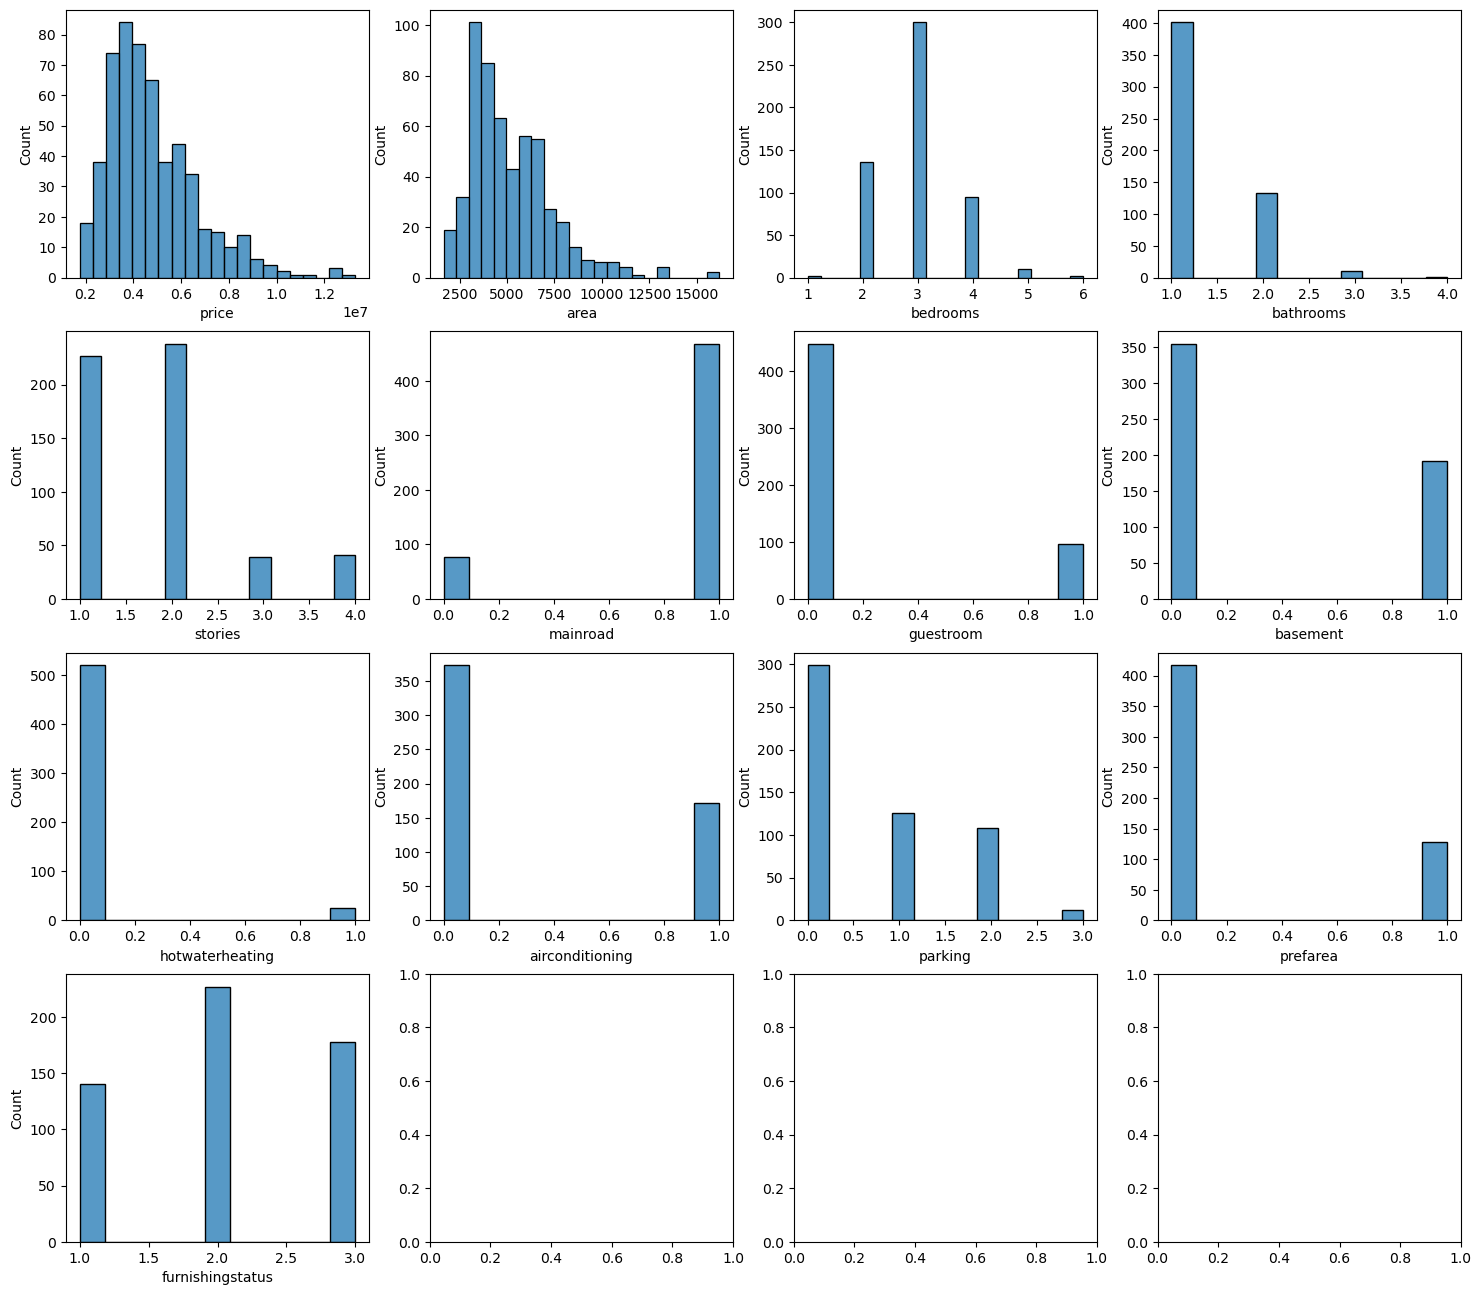

In [80]:
fig, axes = plt.subplots(nrows = 4 ,ncols=4, figsize=(18,16))
for i, column in enumerate(cols_num):
    sns.histplot(df[column],ax=axes[i//4,i%4],kde=False)

### Análisis univariado 

In [81]:
df.groupby('bedrooms').mean(numeric_only=True).T

bedrooms,1,2,3,4,5,6
price,2712500.0,3632022.1,4954598.1,5729757.9,5819800.0,4791500.0
area,3710.0,4636.2,5226.6,5582.1,6291.5,3950.0
bathrooms,1.0,1.1,1.3,1.6,1.8,1.5
stories,1.0,1.2,1.9,2.3,2.0,2.0
mainroad,0.5,0.9,0.9,0.9,0.6,1.0
guestroom,0.0,0.1,0.2,0.2,0.2,0.0
basement,0.0,0.2,0.4,0.4,0.6,0.0
hotwaterheating,0.0,0.0,0.0,0.0,0.2,0.0
airconditioning,0.0,0.2,0.4,0.4,0.3,0.0
parking,0.0,0.5,0.7,0.9,0.6,0.5


In [82]:
df.groupby('bedrooms').median(numeric_only=True).T

bedrooms,1,2,3,4,5,6
price,2712500.0,3535000.0,4620000.0,5250000.0,5582500.0,4791500.0
area,3710.0,4036.0,4830.0,5400.0,5350.0,3950.0
bathrooms,1.0,1.0,1.0,2.0,2.0,1.5
stories,1.0,1.0,2.0,2.0,2.0,2.0
mainroad,0.5,1.0,1.0,1.0,1.0,1.0
guestroom,0.0,0.0,0.0,0.0,0.0,0.0
basement,0.0,0.0,0.0,0.0,1.0,0.0
hotwaterheating,0.0,0.0,0.0,0.0,0.0,0.0
airconditioning,0.0,0.0,0.0,0.0,0.0,0.0
parking,0.0,0.0,0.0,1.0,0.0,0.5


### Análisis bivariado

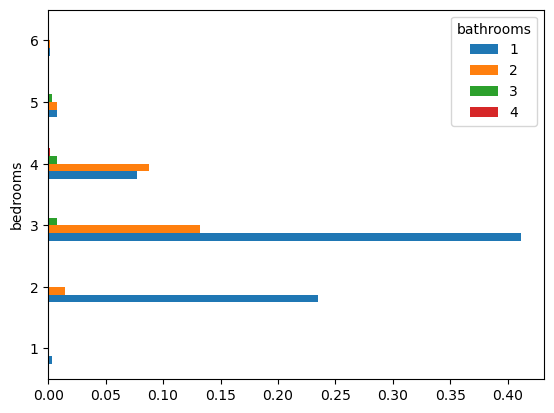

In [83]:
ct = pd.crosstab(df['bedrooms'],df['bathrooms'],normalize=True).plot.barh(stacked=False)

### Matriz de correlación

In [84]:
df.corr( numeric_only=True).style.background_gradient(cmap = 'Blues').set_properties(**{'front_size':'10px'})

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
price,1.000000,0.535997,0.366494,0.517545,0.420712,0.296898,0.255517,0.187057,0.093073,0.452954,0.384394,0.329777,-0.304721
area,0.535997,1.000000,0.151858,0.193820,0.083996,0.288874,0.140297,0.047417,-0.009229,0.222393,0.352980,0.234779,-0.171445
bedrooms,0.366494,0.151858,1.000000,0.373930,0.408564,-0.012033,0.080549,0.097312,0.046049,0.160603,0.139270,0.079023,-0.123244
bathrooms,0.517545,0.193820,0.373930,1.000000,0.326165,0.042398,0.126469,0.102106,0.067159,0.186915,0.177496,0.063472,-0.143559
stories,0.420712,0.083996,0.408564,0.326165,1.000000,0.121706,0.043538,-0.172394,0.018847,0.293602,0.045547,0.044425,-0.104672
mainroad,0.296898,0.288874,-0.012033,0.042398,0.121706,1.000000,0.092337,0.044002,-0.011781,0.105423,0.204433,0.199876,-0.156726
guestroom,0.255517,0.140297,0.080549,0.126469,0.043538,0.092337,1.000000,0.372066,-0.010308,0.138179,0.037466,0.160897,-0.118328
basement,0.187057,0.047417,0.097312,0.102106,-0.172394,0.044002,0.372066,1.000000,0.004385,0.047341,0.051497,0.228083,-0.112831
hotwaterheating,0.093073,-0.009229,0.046049,0.067159,0.018847,-0.011781,-0.010308,0.004385,1.000000,-0.130023,0.067864,-0.059411,-0.031628
airconditioning,0.452954,0.222393,0.160603,0.186915,0.293602,0.105423,0.138179,0.047341,-0.130023,1.000000,0.159173,0.117382,-0.150477


# Generación de variables dummy en el set de datos 


In [85]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

In [86]:
#df = df.dropna()
X = df.drop(['price'],axis=1)
X = pd.get_dummies(X, drop_first = True)
y = df[['price']]

In [87]:
y.head()

,price
0,13300000
1,12250000
2,12250000
3,12215000
4,11410000


# Aplicación de modelo de regresión lineal a la variable Price.
# Entrenamiento, evaluación y predicción de los resultados del modelo.

In [ ]:
# Separar el dataset para el entrenamiento y el test
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=1)

### Muestra del dataset de entrenamiento y prueba

In [89]:
X_train.head(3)

,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
180,4500,4,2,1,0,0,1,0,1,2,0,2
189,3540,2,1,1,0,1,1,0,0,0,0,2
93,7200,3,2,1,1,0,1,0,1,3,0,2


In [114]:
y_train.head(3)

,price
180,5215000
189,5040000
93,6300000


In [115]:
X_test.head(3)

,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
62,6240,4,2,2,1,0,0,0,1,1,0,1
247,8400,4,1,4,1,0,0,0,0,3,0,3
142,10500,4,2,2,1,0,0,0,0,1,0,2


In [116]:
y_test.head(3)

,price
62,7070000
247,4550000
142,5600000


### Regresión lineal

In [117]:
regression_model = LinearRegression()

regression_model.fit(X_train,y_train)

LinearRegression()

### Evaluación del modelo en entrenamiento

In [91]:
regression_model.score(X_train,y_train)

0.6799674103626108

Significa que el modelo explica el 67% de la variación de la variable objetivo en los datos de entrenamiento. Es un buen ajuste un 67%.

### Evaluación del modelo de prueba

In [92]:
regression_model.score(X_test,y_test)

0.6621173401969211

El modelo de regresión lineal obtuvo un coeficiente de determinación (R²) de 0.67 en el conjunto de entrenamiento y de 0.66 en el conjunto de prueba. Esto indica que aproximadamente el 66%-67% de la variabilidad del precio de las viviendas es explicada por las variables incluidas en el modelo. La similitud entre ambos resultados sugiere que el modelo presenta una buena capacidad de generalización y no muestra signos significativos de sobreajuste.

# Análisis de Sensibilidad e importancia de variables.

# Visualización de los resultados del modelo de regresión

### Predicción del dataset de prueba

In [93]:
y_pred = regression_model.predict(X_test)

In [94]:
df_preds = pd.DataFrame({'Actual':y_test.squeeze(),'Predicted':y_pred.squeeze()})
print(df_preds)

      Actual  Predicted
62   7070000  6291567.1
247  4550000  6390833.3
142  5600000  6529768.6
107  6125000  5564502.0
483  2940000  4230599.3
..       ...        ...
450  3150000  4008865.1
542  1750000  2717347.4
408  3430000  2810959.6
80   6629000  5677214.5
46   7525000  7236802.7

[164 rows x 2 columns]


### MAE, MSE y RMSE

In [97]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

y_pred = regression_model.predict(X_test)
mae = mean_absolute_error(y_test,y_pred)
mse = mean_squared_error(y_test,y_pred)
rmse = np.sqrt(mse)

In [98]:
print(f'Mean absolute error: {mae:.2f}')
print(f'Mean squared error: {mse:.2f}')
print(f'Root mean squared error: {rmse:.2f}')

Mean absolute error: 855894.77
Mean squared error: 1375329793553.13
Root mean squared error: 1172744.56


### Intercept y Coeficientes del modelo de regresión

In [99]:
for idx, col_name in enumerate(X_train.columns):
    print('Coef {} = {}'.format(col_name,regression_model.coef_[0][idx]))

Coef area = 246.34768711251942
Coef bedrooms = 47198.862725111656
Coef bathrooms = 1020173.2432420903
Coef stories = 525778.9633518041
Coef mainroad = 476712.9848125422
Coef guestroom = 275668.9507600048
Coef basement = 557956.2675518359
Coef hotwaterheating = 822714.5575357177
Coef airconditioning = 608777.0120530989
Coef parking = 274736.44997549383
Coef prefarea = 500668.03295517794
Coef furnishingstatus = -202462.66994588563


In [100]:
coeff_data = pd.DataFrame({
    'Var': ['Intercept'] + list(X_train.columns),
    'Coeff': [regression_model.intercept_[0]] + list(regression_model.coef_[0])
})

coeff_data

,Var,Coeff
0,Intercept,315893.9
1,area,246.3
2,bedrooms,47198.9
3,bathrooms,1020173.2
4,stories,525779.0
5,mainroad,476713.0
6,guestroom,275669.0
7,basement,557956.3
8,hotwaterheating,822714.6
9,airconditioning,608777.0


In [101]:
Equation = 'Price = '
print(Equation, end='')

for i in range(len(coeff_data)):
    coeff = coeff_data.iloc[i]['Coeff']
    var = coeff_data.iloc[i]['Var']

    if i < len(coeff_data) - 1:
        print(f'({coeff}) * {var} + ', end='')
    else:
        print(f'({coeff}) * {var}')

Price = (315893.9013970634) * Intercept + (246.34768711251942) * area + (47198.862725111656) * bedrooms + (1020173.2432420903) * bathrooms + (525778.9633518041) * stories + (476712.9848125422) * mainroad + (275668.9507600048) * guestroom + (557956.2675518359) * basement + (822714.5575357177) * hotwaterheating + (608777.0120530989) * airconditioning + (274736.44997549383) * parking + (500668.03295517794) * prefarea + (-202462.66994588563) * furnishingstatus


# Análisis de Sensibilidad e importancia de variables.

Text(0.5, 1.0, 'Comparación de Predicción (x) vs Real (y)')

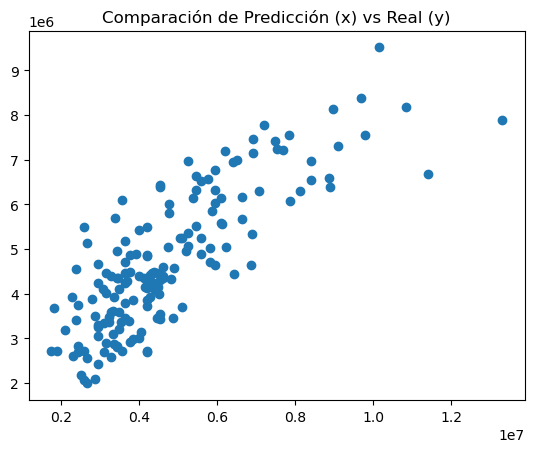

In [102]:
predictions = regression_model.predict(X_test)
plt.scatter(y_test,predictions)
plt.title('Comparación de Predicción (x) vs Real (y)')

El gráfico de dispersión entre los valores predichos y los valores reales muestra una relación positiva clara. A medida que aumentan los valores reales de las viviendas, también aumentan las predicciones generadas por el modelo, lo que indica que la regresión captura adecuadamente la tendencia general de los datos.

Text(0.5, 1.0, 'Residuals')

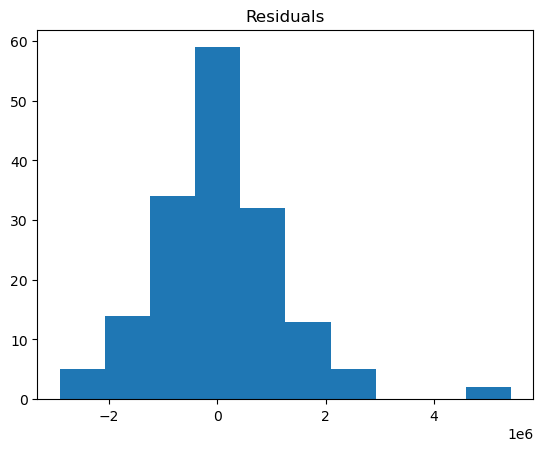

In [103]:
plt.hist(y_test - predictions)
plt.title('Residuals')

### Muestra de base de datos

In [104]:
df.sample(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
475,2961000,3000,2,1,2,1,0,0,0,0,0,0,2
176,5250000,8520,3,1,1,1,0,0,0,1,2,0,1
11,9681000,6000,4,3,2,1,1,1,1,0,2,0,2
125,5943000,15600,3,1,1,1,0,0,0,1,2,0,2
461,3080000,4960,2,1,1,1,0,1,0,1,0,0,3
159,5460000,3150,3,2,1,1,1,1,0,1,0,0,1
448,3150000,4095,2,1,1,1,0,0,0,0,2,0,2
189,5040000,3540,2,1,1,0,1,1,0,0,0,0,2
353,3780000,2856,3,1,3,1,0,0,0,0,0,1,1
387,3500000,4240,3,1,2,1,0,0,0,1,0,0,2


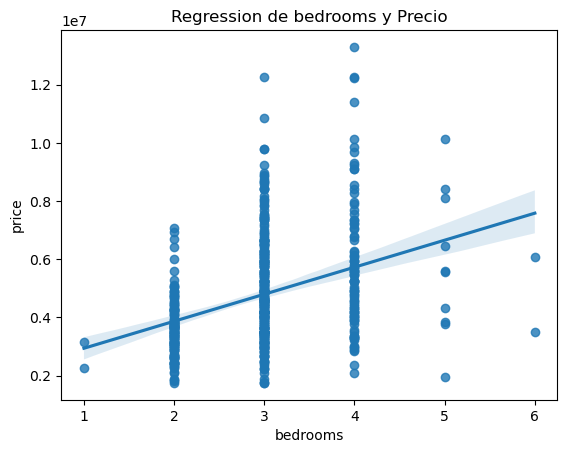

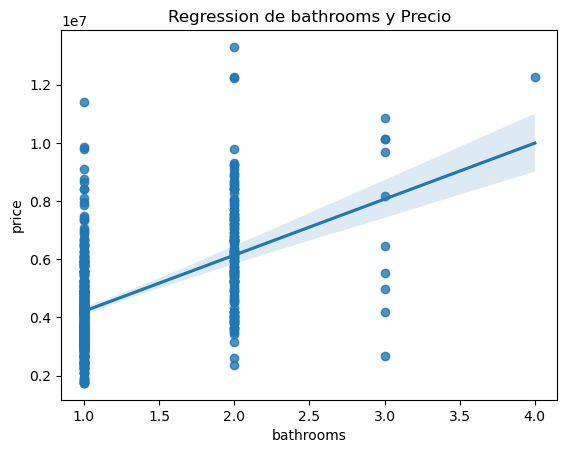

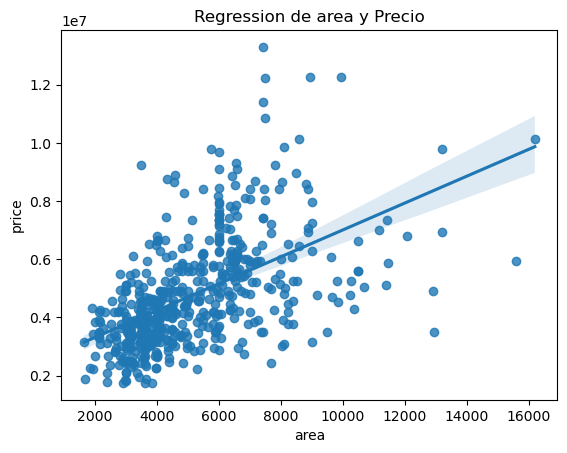

In [118]:
import seaborn as sns

variables = ['bedrooms','bathrooms','area']

for var in variables:
    plt.figure()
    sns.regplot(x=var,y='price',data=df).set(title=f'Regression de {var} y Precio')

La gráfica de regresión evidencia una relación positiva entre el número de habitaciones y el precio de la vivienda. La pendiente ascendente de la línea de regresión indica que, en promedio, las viviendas con más habitaciones tienden a tener precios más elevados.
La gráfica de regresión evidencia una relación positiva entre el número de baños y el precio de la vivienda. La pendiente ascendente de la línea de regresión indica que, en promedio, las viviendas con más baños tienden a tener precios más elevados.
Este gráfico muestra una relación más fuerte entre área y precio que la observada entre bedrooms y precio, y habitaciones y precio.

In [106]:
y_pred_df = pd.DataFrame(y_pred,columns = ['pred_price'])

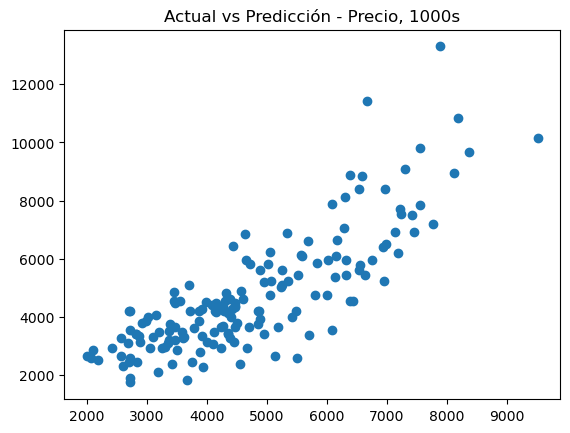

In [107]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()
ax.ticklabel_format(style='plain')
plt.title('Actual vs Predicción - Precio, 1000s')
plt.scatter(y_pred_df.pred_price/1000, y_test.price/1000)

El gráfico de dispersión entre los valores reales y los valores predichos muestra una relación positiva clara, indicando que el modelo es capaz de capturar la tendencia general de los precios de las viviendas. A medida que aumenta el precio real, las predicciones también tienden a incrementarse.

# Conclusiones

Puedes redactarlo de forma más técnica y fluida:
La variable área presenta la relación positiva más fuerte con la variable objetivo (precio), en comparación con el resto de las variables explicativas. Esto indica que, a medida que aumenta el área de la propiedad, el precio tiende a incrementarse de manera más significativa.
El modelo de regresión lineal muestra un buen nivel de ajuste, con un coeficiente de determinación (R²) de 0.67, lo que significa que el modelo es capaz de explicar aproximadamente el 67% de la variabilidad observada en el precio.
En el conjunto de prueba, el modelo obtuvo un R² de 0.66, un valor muy cercano al obtenido en entrenamiento. Esta diferencia mínima sugiere que no existe evidencia significativa de sobreajuste (overfitting) y que el modelo tiene una buena capacidad de generalización, explicando aproximadamente el 66% de la variabilidad del precio en datos no vistos.